# LangGraph Agent
Building a Travel Planner with a Simple LangGraph Agent. 
This example demonstrates how to create a travel planner using a LangGraph agent. The process of creating a simple Travel Planner using LangGraph, a library for building stateful, multi-step applications with language models. The Travel Planner demonstrates how to structure a conversational AI application that collects user input and generates personalized travel itineraries.

## Setup and Imports

In [1]:
%%time
import warnings
warnings.filterwarnings("ignore")

!python3 -m pip install --upgrade pip

CPU times: user 6.88 ms, sys: 9.68 ms, total: 16.6 ms
Wall time: 729 ms


In [2]:
%pip install -U -q langchain langchain-core langchain-ollama ragas transformers langgraph langchain_community faker faiss-cpu duckduckgo-search wikipedia PyPDF2 rapidfuzz certifi requests urllib3 ipython-autotime --use-deprecated=legacy-resolver

%load_ext autotime

ERROR: pip's legacy dependency resolver does not consider dependency conflicts when selecting packages. This behaviour is the source of the following dependency conflicts.
langchain-cohere 0.3.5 requires langchain-core<0.4.0,>=0.3.27, but you'll have langchain-core 1.1.2 which is incompatible.
embedchain 0.1.128 requires chromadb<0.6.0,>=0.5.10, but you'll have chromadb 1.1.1 which is incompatible.
embedchain 0.1.128 requires langchain<0.4.0,>=0.3.1, but you'll have langchain 1.1.2 which is incompatible.
embedchain 0.1.128 requires langchain-community<0.4.0,>=0.3.1, but you'll have langchain-community 0.4.1 which is incompatible.
langchain-huggingface 0.3.0 requires langchain-core<1.0.0,>=0.3.65, but you'll have langchain-core 1.1.2 which is incompatible.
app 0.1.0 requires tenacity<9.0.0,>=8.2.3, but you'll have tenacity 9.1.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
time: 155 μs (started: 2025-12-08 09:15:32 -08:00)


In [3]:
from IPython.display import display, Image

# BEGIN: fix Python or Notebook SSL CERTIFICATE_VERIFY_FAILED
# SSLCertVerificationError: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)
import os, ssl

if not os.environ.get("PYTHONHTTPSVERIFY", "") and getattr(
    ssl, "_create_unverified_context", None
):
    ssl._create_default_https_context = ssl._create_unverified_context
# END: fix Python or Notebook SSL CERTIFICATE_VERIFY_FAILED

time: 413 μs (started: 2025-12-08 09:15:32 -08:00)


## Define Agent State
I will define the state that our agent will maintain throughout its operation. First, define the [State](https://docs.langchain.com/oss/python/langgraph/graph-api#state) of the graph. The State schema serves as the input schema for all Nodes and Edges in the graph.

In [4]:
from typing import TypedDict, Annotated, List
from langchain_core.messages import HumanMessage, AIMessage


class PlannerState(TypedDict):
    messages: Annotated[
        List[HumanMessage | AIMessage], "The messages in the conversation"
    ]
    itinerary: str
    city: str
    user_message: str

time: 132 ms (started: 2025-12-08 09:15:32 -08:00)


## Set Up Language Model and Prompts

In [5]:
my_model_ollama = "llama3.2"

from langchain_ollama.llms import OllamaLLM

llm_client = OllamaLLM(
    model=my_model_ollama,
    base_url="http://localhost:11434",
    headers={"Content-Type": "application/json"},
    stream=False,
)

llm_client

OllamaLLM(model='llama3.2', base_url='http://localhost:11434')

time: 1.61 s (started: 2025-12-08 09:15:32 -08:00)


In [6]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

itinerary_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a helpful travel assistant. Create a day trip itinerary for {city} based on the user's interests. 
    Follow these instructions:
    1. Use the below chat conversation and the latest input from Human to get the user interests.
    2. Always account for travel time and meal times - if its not possible to do everything, then say so.
    3. If the user hasn't stated a time of year or season, assume summer season in {city} and state this assumption in your response.
    4. If the user hasn't stated a travel budget, assume a reasonable dollar amount and state this assumption in your response.
    5. Provide a brief, bulleted itinerary in chronological order with specific hours of day.""",
        ),
        MessagesPlaceholder("chat_history"),
        ("human", "{user_message}"),
    ]
)

itinerary_prompt

ChatPromptTemplate(input_variables=['chat_history', 'city', 'user_message'], input_types={'chat_history': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='SystemMessageChunk')], typ

time: 12.4 ms (started: 2025-12-08 09:15:34 -08:00)


## Define the nodes and Edges
Adding the nodes, edges as well as a persistant memory to the [StateGraph](https://docs.langchain.com/oss/python/langgraph/graph-api#stategraph) before we compile it.

- user travel plans
- invoke with Bedrock
- generate the travel plan for the day
- ability to add or modify the plan

In [7]:
def input_interests(state: PlannerState) -> PlannerState:
    user_message = state["user_message"]  # input("Your input: ")
    # print(f"We are going to :: {user_message}:: for trip to {state['city']} based on your interests mentioned in the prompt....")

    if not state.get("messages", None):
        state["messages"] = []
    return {
        **state,
    }


def create_itinerary(state: PlannerState) -> PlannerState:
    response = llm_client.invoke(
        itinerary_prompt.format_messages(
            city=state["city"],
            user_message=state["user_message"],
            chat_history=state["messages"],
        )
    )
    print("\nFinal Itinerary:")
    print(response.content)
    return {
        **state,
        "messages": state["messages"]
        + [
            HumanMessage(content=state["user_message"]),
            AIMessage(content=response.content),
        ],
        "itinerary": response.content,
    }

time: 420 μs (started: 2025-12-08 09:15:34 -08:00)


## Create and Compile the Graph
Create our LangGraph workflow and compile it.

- First, we initialize a StateGraph with the State class we defined above.
- Then, we add our nodes and edges.
- We use the [START Node](https://docs.langchain.com/oss/python/langgraph/graph-api#start-node), a special node that sends user input to the graph, to indicate where to start our graph.
- The [END Node](https://docs.langchain.com/oss/python/langgraph/graph-api#start-node) is a special node that represents a terminal node.

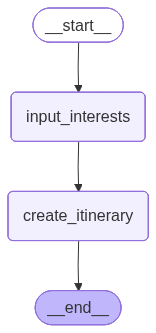

Graph compiled and rendered successfully!


ValueError: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

time: 1.46 s (started: 2025-12-08 09:15:34 -08:00)


In [8]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
import ssl

# Disable SSL verification to avoid certificate errors
# This is a workaround for SSL certificate verification issues with mermaid.ink API
try:
    import urllib3

    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
except ImportError:
    pass  # urllib3 not available, but that's okay

# Create an unverified SSL context
ssl._create_default_https_context = ssl._create_unverified_context

workflow = StateGraph(PlannerState)
workflow.add_node("input_interests", input_interests)
workflow.add_node("create_itinerary", create_itinerary)
workflow.set_entry_point("input_interests")
workflow.add_edge("input_interests", "create_itinerary")
workflow.add_edge("create_itinerary", END)

# The checkpointer lets the graph persist its state
# this is a complete memory for the entire graph.
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

# Display the graph - SSL verification is disabled globally above
try:
    import requests

    # Temporarily patch requests to disable SSL verification
    original_get = requests.get
    original_session_request = requests.Session.request

    def patched_get(*args, **kwargs):
        kwargs["verify"] = False
        return original_get(*args, **kwargs)

    def patched_session_request(self, *args, **kwargs):
        kwargs["verify"] = False
        return original_session_request(self, *args, **kwargs)

    requests.get = patched_get
    requests.Session.request = patched_session_request

    try:
        graph_image = app.get_graph().draw_mermaid_png()
        display(Image(graph_image))
        print("Graph compiled and rendered successfully!")
    finally:
        # Restore original methods
        requests.get = original_get
        requests.Session.request = original_session_request

except Exception as e:
    # Fallback: Display mermaid text representation
    print("Note: Could not render graph as PNG image.")
    print(f"Error: {e}")
    print(
        "\nGraph Mermaid syntax (you can copy this to https://mermaid.live/ to visualize):"
    )
    print("=" * 80)
    try:
        mermaid_syntax = app.get_graph().draw_mermaid()
        print(mermaid_syntax)
    except Exception as e2:
        print(f"Could not get mermaid syntax: {e2}")
    print("=" * 80)
    print("\nGraph structure:")
    print(app)

# Return the app object
app